In [18]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

book_data_raw = pd.read_csv(r"C:\Users\ldiaz\OneDrive\Desktop\CHE 4230\Semester Project\data\best sellin books total.csv")
print(book_data_raw)

                                             Book name  \
0    Atomic Habits: An Easy & Proven Way to Build G...   
1      Iron Flame (Standard Edition) (The Empyrean, 2)   
2                                                Spare   
3                                          Fourth Wing   
4                                      The Woman in Me   
..                                                 ...   
205            A People's History of the United States   
206                                          Bob Books   
207                                         Alchemised   
208       The Next Conversation: Argue Less, Talk More   
209                     A Beautiful Year in the Bible:   

                                        Author              Rating  \
0                                  James Clear  4.8 out of 5 stars   
1                               Rebecca Yarros  4.7 out of 5 stars   
2             Prince Harry  The Duke of Sussex  4.5 out of 5 stars   
3                      

In [19]:
book_data_raw.describe()

,reviews count,Print Length
count,210.000000,210.000000
mean,90436.204762,354.185714
std,115795.102175,397.047957
min,476.000000,12.000000
25%,13721.750000,141.000000
50%,40693.500000,320.000000
75%,115439.250000,432.000000
max,653111.000000,4200.000000


In [20]:
book_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Book name        210 non-null    object
 1   Author           210 non-null    object
 2   Rating           210 non-null    object
 3   reviews count    210 non-null    int64 
 4   form             210 non-null    object
 5   price            210 non-null    object
 6   Reading age      71 non-null     object
 7   Print Length     210 non-null    int64 
 8   Publishing date  210 non-null    object
 9   Genre            210 non-null    object
 10  id_2023          100 non-null    object
 11  id_2024          110 non-null    object
 12  id_2025          98 non-null     object
dtypes: int64(2), object(11)
memory usage: 21.5+ KB


In [ ]:
#first run of csv file gave 2 instances of null data in print length, so I looked up the information and put it into the csv file
print(book_data_raw.isnull().sum()) #null data present in reading age and id numbers
#ID numbers not needed, so they will be removed


Book name            0
Author               0
Rating               0
reviews count        0
form                 0
price                0
Reading age        139
Print Length         0
Publishing date      0
Genre                0
id_2023            110
id_2024            100
id_2025            112
dtype: int64


In [ ]:
book_data_raw.columns = book_data_raw.columns.str.strip()
print(list(book_data_raw.columns))

['Book name', 'Author', 'Rating', 'reviews count', 'form', 'price', 'Reading age', 'Print Length', 'Publishing date', 'Genre']


In [ ]:
print(book_data_raw.isnull().sum()) #the id_202X columsn were removed, now only 1 column has null data

Book name            0
Author               0
Rating               0
reviews count        0
form                 0
price                0
Reading age        139
Print Length         0
Publishing date      0
Genre                0
dtype: int64


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

train_frac = 70
val_frac = 15
test_frac = 15

val_size = val_frac / (100 - test_frac)
test_size = test_frac / 100

# -----------------------------
# 1. Train/Val/Test Split
# -----------------------------
x_train_val, x_test = train_test_split(
    book_data_raw,
    test_size=test_size,
    random_state=42
)

x_train, x_val = train_test_split(
    x_train_val,
    test_size=val_size,
    random_state=42
)

print(f"Training set:   {x_train.shape} (approx {100 - val_frac - test_frac}%)")
print(f"Validation set: {x_val.shape} (approx {val_frac}%)")
print(f"Test set:       {x_test.shape} (approx {test_frac}%)")
print(f"Total samples:  {len(x_train) + len(x_val) + len(x_test)}")

# -----------------------------
# 2. One-Hot Encode Categorical Columns (OPTION 3)
# -----------------------------
x_train = pd.get_dummies(x_train)
x_val   = pd.get_dummies(x_val)
x_test  = pd.get_dummies(x_test)

# Align columns so all sets match
x_val  = x_val.reindex(columns=x_train.columns, fill_value=0)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

# -----------------------------
# 3. Scale Numeric Data
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_val_scaled   = scaler.transform(x_val)
X_test_scaled  = scaler.transform(x_test)

# -----------------------------
# 4. PCA
# -----------------------------
pca = PCA(n_components=2)
pca_train = pca.fit_transform(X_train_scaled)
pca_val   = pca.transform(X_val_scaled)
pca_test  = pca.transform(X_test_scaled)

Training set:   (146, 10) (approx 70%)
Validation set: (32, 10) (approx 15%)
Test set:       (32, 10) (approx 15%)
Total samples:  210


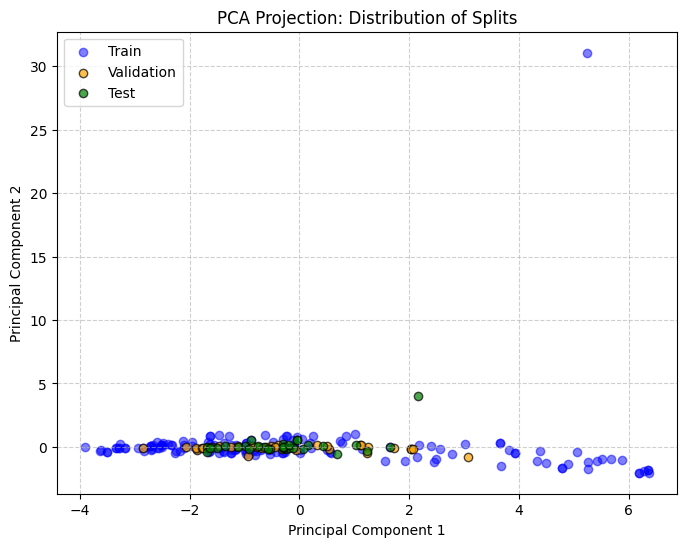

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_train[:, 0], pca_train[:, 1], alpha=0.5, label='Train', c='blue')
plt.scatter(pca_val[:, 0], pca_val[:, 1], alpha=0.7, label='Validation', c='orange', edgecolors='k')
plt.scatter(pca_test[:, 0], pca_test[:, 1], alpha=0.7, label='Test', c='green', edgecolors='k')

plt.title("PCA Projection: Distribution of Splits")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()